In [ ]:
''' Hammad Usmani
PURPOSE: To provide a class and API for the HURDAT2 database
METHOD: Read the text file provided by the NOAA and NHC into a pandas DataFrame and
  create an API for common functions and applications.
INPUT: HURDAT2 database http://www.nhc.noaa.gov/data/#hurdat
'''
import pandas as pd
import numpy as np
import datetime
import io

class hurdat2 :
    hurricanes = pd.DataFrame()

    '''
    PURPOSE: Initialize the HURDAT2 API class
    METHOD: Read in the text file with the NHC data into hurricanes DataFrame
    OUTPUT: Success / Failure dialogue
    '''
    def __init__(self, filename = "hurdat2.txt") :
        self.hurricanes = self.parse(filename)
        return
    '''
    PURPOSE: Parse in HURDAT2 database
    METHOD: Use the HURDAT2 format provided by the NHC and NOAA
    OUTPUT: pandas DataFrame with appropriate data
    REFERENCES:
        [1] http://www.nhc.noaa.gov/data/hurdat/hurdat2-format-atlantic.pdf
    '''
    def parse(self, filename = "/hurdat2.txt", encoding="utf-8") :
        db = []

        # Begin parsing by reading in line by line
        with open(filename) as raw :
            for line in raw :
                line = line.replace(' ', '').split(',')

                # Identify atlantic storm, first 2 letters should be AL
                if (line[0][:2] == 'AL') :
                    storm_id = line[0]
                    storm_name = line[1]
                    storm_entries = line[2]

                    # Iterate and read through best track entries
                    for i in range(int(storm_entries)) :
                        entry = raw.readline().replace(' ', '').split(',')
                        # Filter -999 placeholder for missing central pressure
                        entry = [None if x == "-999" else x for x in entry]
                        # Construct date and time based on first two columns
                        timestamp = datetime.datetime(int(entry[0][:4]), int(entry[0][4:6]), int(entry[0][6:8]), int(entry[1][:2]), int(entry[1][3:]))
                        # Add entry into our current database
                        db.append([storm_id, storm_name, timestamp] + entry[2:-1])
                else :
                    print("Error, unidentified storm ".join(str(line[0])))

        # Return DataFrame
        return pd.DataFrame(db, columns = ['storm_id', 'storm_name', 'entry_time', 'entry_id', 'entry_status', 'lat', 'long','max_wind', 'min_pressure', '34kt_ne', '34kt_se', '34kt_sw', '34kt_nw', '50kt_ne', '50kt_se', '50kt_sw', '50kt_nw', '64kt_ne', '64kt_se', '64kt_sw', '64kt_nw'])

In [ ]:
!wget "https://www.nhc.noaa.gov/data/hurdat/hurdat2-1851-2024-040425.txt"

--2025-07-07 01:08:21--  https://www.nhc.noaa.gov/data/hurdat/hurdat2-1851-2024-040425.txt
Resolving www.nhc.noaa.gov (www.nhc.noaa.gov)... 3.166.160.104, 3.166.160.89, 3.166.160.49, ...
Connecting to www.nhc.noaa.gov (www.nhc.noaa.gov)|3.166.160.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7034638 (6.7M) [text/plain]
Saving to: ‘hurdat2-1851-2024-040425.txt’

hurdat2-1851-2024-0 100%[===================>]   6.71M  --.-KB/s    in 0.1s    

2025-07-07 01:08:22 (47.6 MB/s) - ‘hurdat2-1851-2024-040425.txt’ saved [7034638/7034638]



In [ ]:
data = hurdat2('hurdat2-1851-2024-040425.txt')

In [ ]:
df = data.hurricanes

In [ ]:
df.head()

,storm_id,storm_name,entry_time,entry_id,entry_status,lat,long,max_wind,min_pressure,34kt_ne,...,34kt_sw,34kt_nw,50kt_ne,50kt_se,50kt_sw,50kt_nw,64kt_ne,64kt_se,64kt_sw,64kt_nw
0,AL011851,UNNAMED,1851-06-25 00:00:00,,HU,28.0N,94.8W,80,None,None,...,None,None,None,None,None,None,None,None,None,None
1,AL011851,UNNAMED,1851-06-25 06:00:00,,HU,28.0N,95.4W,80,None,None,...,None,None,None,None,None,None,None,None,None,None
2,AL011851,UNNAMED,1851-06-25 12:00:00,,HU,28.0N,96.0W,80,None,None,...,None,None,None,None,None,None,None,None,None,None
3,AL011851,UNNAMED,1851-06-25 18:00:00,,HU,28.1N,96.5W,80,None,None,...,None,None,None,None,None,None,None,None,None,None
4,AL011851,UNNAMED,1851-06-25 21:00:00,L,HU,28.2N,96.8W,80,None,None,...,None,None,None,None,None,None,None,None,None,None


In [ ]:
df.columns

Index(['storm_id', 'storm_name', 'entry_time', 'entry_id', 'entry_status',
       'lat', 'long', 'max_wind', 'min_pressure', '34kt_ne', '34kt_se',
       '34kt_sw', '34kt_nw', '50kt_ne', '50kt_se', '50kt_sw', '50kt_nw',
       '64kt_ne', '64kt_se', '64kt_sw', '64kt_nw'],
      dtype='object')

In [ ]:
# filter to entries where there was a severe storm, Category 3 (Saffir-Simpson scale) or higher
threshold = 96 #kt, https://www.nhc.noaa.gov/aboutsshws.php
severe_df = df[df['max_wind'].astype('int') > threshold]
# The data quality improved since 1970 and based on that we can use this optional filter
# severe_df = severe_df[severe_df['entry_time'].map(lambda x: x.year) > 1970]
severe_df.sample(5)

,storm_id,storm_name,entry_time,entry_id,entry_status,lat,long,max_wind,min_pressure,34kt_ne,...,34kt_sw,34kt_nw,50kt_ne,50kt_se,50kt_sw,50kt_nw,64kt_ne,64kt_se,64kt_sw,64kt_nw
16448,AL041932,UNNAMED,1932-09-06 12:00:00,,HU,27.5N,77.4W,140,None,None,...,None,None,None,None,None,None,None,None,None,None
40697,AL071997,ERIKA,1997-09-08 12:00:00,,HU,22.5N,62.9W,105,957,None,...,None,None,None,None,None,None,None,None,None,None
10206,AL021903,UNNAMED,1903-08-09 18:00:00,,HU,14.9N,64.7W,105,None,None,...,None,None,None,None,None,None,None,None,None,None
53395,AL182021,SAM,2021-10-02 00:00:00,,HU,30.8N,61.5W,125,940,150,...,130,130,80,90,70,70,50,45,35,35
17938,AL031935,UNNAMED,1935-09-02 18:00:00,,HU,24.1N,80.0W,135,None,None,...,None,None,None,None,None,None,None,None,None,None


<Axes: ylabel='Frequency'>

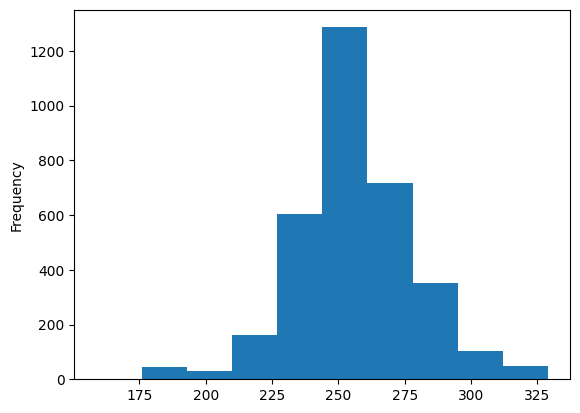

In [ ]:
times = severe_df['entry_time'].map(lambda x: x.timetuple().tm_yday)
times.plot.hist()

In [ ]:
times.describe()

,entry_time
count,3345.000000
mean,255.811659
std,22.330725
min,159.000000
25%,243.000000
50%,254.000000
75%,270.000000
max,329.000000


In [ ]:
from datetime import datetime, timedelta
def day_count_text(day_count, formatter = '%B %-d'):
  timeline = datetime(2025, 1, 1) + timedelta(days = day_count - 1)
  return timeline.strftime(formatter)

In [ ]:
import numpy as np
from scipy import stats

# 95% confidence interval
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.tstd.html#scipy.stats.tstd
times_mean, times_std = np.mean(times), stats.tstd(times)
print(f"Mean: {round(times_mean)} ({day_count_text(round(times_mean))})")
print(f"Standard Deviation: {round(times_std)} days")
times_interval = stats.norm.interval(confidence=0.95, loc=times_mean, scale=times_std)
print(f"95% Confidence Interval: {day_count_text(round(times_interval[0]))} to {day_count_text(round(times_interval[1]))}")


Mean: 256 (September 13)
Standard Deviation: 22 days
95% Confidence Interval: July 31 to October 27


In [ ]:
# Perform one-sample t-test
times_original = np.mean(df['entry_time'].map(lambda x: x.timetuple().tm_yday))
t_stat, p_value = stats.ttest_1samp(times, times_original)
print("T statistic:", t_stat)
print("P-value:", p_value)

T statistic: 12.64204769868098
P-value: 8.064966456422598e-36
